In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112475 entries, 0 to 112474
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   dteday        112475 non-null  object 
 1   hr            112475 non-null  float64
 2   casual        112475 non-null  int64  
 3   registered    112475 non-null  int64  
 4   temp_c        112475 non-null  float64
 5   feels_like_c  112475 non-null  float64
 6   hum           112475 non-null  float64
 7   windspeed     112475 non-null  float64
 8   weathersit    112475 non-null  int64  
 9   season        112475 non-null  int64  
 10  holiday       112475 non-null  int64  
 11  workingday    112475 non-null  int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 10.3+ MB


In [ ]:
df.head(5)

,dteday,hr,casual,registered,temp_c,feels_like_c,hum,windspeed,weathersit,season,holiday,workingday
0,1/1/2011,0.0,3,13,3.0,3.0,0.7957,0.8,1,1,0,0
1,1/1/2011,1.0,8,30,1.7,1.7,0.8272,0.8,1,1,0,0
2,1/1/2011,2.0,5,26,1.9,1.9,0.8157,1.1,1,1,0,0
3,1/1/2011,3.0,3,9,2.5,2.5,0.7831,0.8,1,1,0,0
4,1/1/2011,4.0,0,1,2.0,2.0,0.8075,1.1,1,1,0,0


In [ ]:
def dataClean(data):
  dateTime = pd.to_datetime(data['dteday'])
  dateTime = dateTime.apply(lambda x: x.toordinal()) * 24 + data['hr']
  data['dateTime'] = dateTime
  data['daylight'] = np.sin(data['hr']/24*np.pi*2)

  data['dteday'] = pd.to_datetime(data['dteday'])
  # get year
  data['year'] = data['dteday'].dt.year
  data['month'] = data['dteday'].dt.month
  data['day'] = data['dteday'].dt.day
  data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
  data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
  data['day_sin'] = np.sin(2 * np.pi * data['day'] / 31)  # Max 31 days in a month
  data['day_cos'] = np.cos(2 * np.pi * data['day'] / 31)
  data['hr_sin'] = np.sin(2 * np.pi * data['hr'] / 24)
  data['hr_cos'] = np.cos(2 * np.pi * data['hr'] / 24)
  data['possible_worker'] = np.where((data['hr'] >= 7.5) & (data['hr'] <= 17.5) & (data['workingday'] == 1), 1, 0)
  data['covid_years'] = np.where(data['year'].isin([2020, 2021]), 1, 0)

  def hour_bin(x):
      if x in [0, 1, 2, 3, 4, 5]:
          return 0
      elif x in [7, 8]:
          return 1
      elif x in [11, 12, 13, 14, 15, 16]:
          return 2
      elif x in [17, 18, 19]:
          return 3
      else:
          return 4
  def temp_bin(x):
      if x < 0:
          return 1
      elif x in range(10, 36):
          return 2
      else:
          return 3



  b = 17.625
  c = 243.04
  gamma = np.log(data['hum'] / 100) + (b * data['temp_c']) / (c + data['temp_c'])
  data['dew_point'] = (c * gamma) / (b - gamma)

  data['hour_bin'] = data['hr'].apply(hour_bin)
  data['tempt_bin'] = data['temp_c'].apply(temp_bin)
  data['prime_conditions'] = (
      (data['hour_bin'].isin([1, 3, 2]))
      & (data['tempt_bin'] == 2 )
  ).astype(int)
  # get dummies
  data = pd.get_dummies(data, columns=['season', 'holiday', 'workingday', 'weathersit'])
  # one hot encode hour_bin
  # data = pd.get_dummies(data, columns=['hour_bin'])
  data.drop(columns=['dteday','hr'], inplace=True)


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv')
dataClean(df)

In [ ]:
features = ['dateTime', 'season', 'holiday', 'workingday', 'weathersit', 'temp_c', 'feels_like_c', 'hum', 'daylight','windspeed','month_sin','month_cos','day_sin','day_cos',
            'hr_sin','hr_cos','hour_bin','prime_conditions','possible_worker','dew_point']
X = df[features]
y = df['casual'] + df['registered']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

In [ ]:
norm = MinMaxScaler().fit(X_train)
X_train = norm.transform(X_train)
X_test = norm.transform(X_test)

In [ ]:
model = Sequential()
model.add(Dense(64, input_dim=len(X_train[0]), activation='relu'))
model.add(Dropout(.1))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = keras.optimizers.Adam()
model.compile(loss="mean_squared_error", optimizer=opt, metrics=['mse'])

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_mse', patience=10)

history = model.fit(X_train, y_train, epochs=50, validation_split=.35, batch_size=50, callbacks=[early_stop],shuffle=False)

Epoch 1/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9610.5947 - mse: 9610.5947 - val_loss: 8436.0234 - val_mse: 8436.0234
Epoch 2/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9487.4150 - mse: 9487.4141 - val_loss: 8442.1865 - val_mse: 8442.1865
Epoch 3/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9347.5947 - mse: 9347.5938 - val_loss: 8448.8340 - val_mse: 8448.8340
Epoch 4/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9278.1680 - mse: 9278.1680 - val_loss: 8392.0264 - val_mse: 8392.0264
Epoch 5/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9659.5234 - mse: 9659.5234 - val_loss: 8605.0947 - val_mse: 8605.0947
Epoch 6/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9585.4043 - mse: 9585.4043 - val_loss: 8481.8369 - val_mse: 8481.8369
Epoch 7/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 9415.9082 - mse: 9415.9082 - val_loss: 8444.1416 - val_mse: 8444.1416
Epoch 8/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9455.5674 - ms

In [ ]:
hist = pd.DataFrame(history.history)

In [ ]:
hist = hist.reset_index()


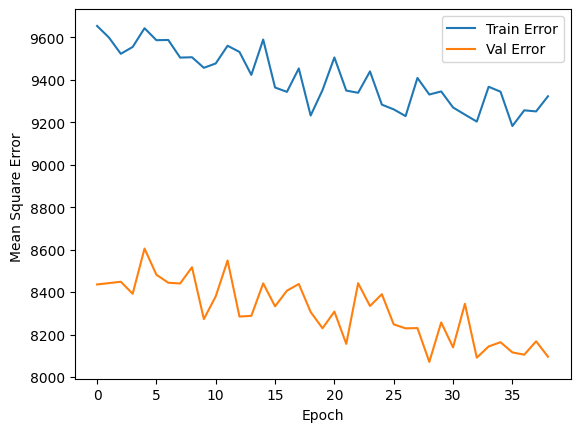

In [ ]:
def plot_history():
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error ')
    plt.plot(hist['index'], hist['mse'], label='Train Error')
    plt.plot(hist['index'], hist['val_mse'], label = 'Val Error')
    plt.legend()
    # plt.ylim([0,50])

plot_history()

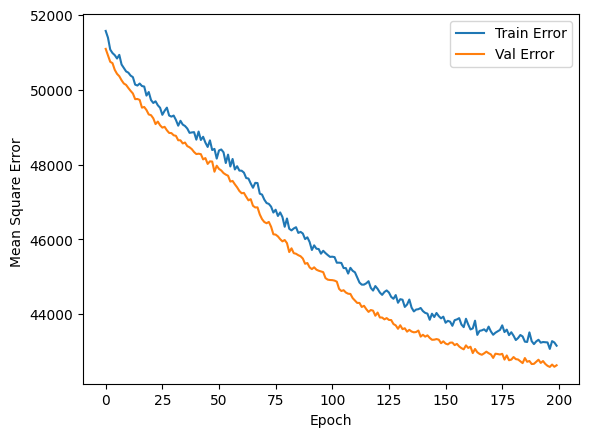

In [ ]:
def plot_history():
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error ')
    plt.plot(hist['index'], hist['mse'], label='Train Error')
    plt.plot(hist['index'], hist['val_mse'], label = 'Val Error')
    plt.legend()
    # plt.ylim([0,50])

plot_history()

In [ ]:
predictions = np.round(model.predict(X_test),1)

1055/1055 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
result = root_mean_squared_error(y_test, predictions)
result

89.28753662109375

In [ ]:
r2 = r2_score(y_test,predictions)
r2

0.931315004825592

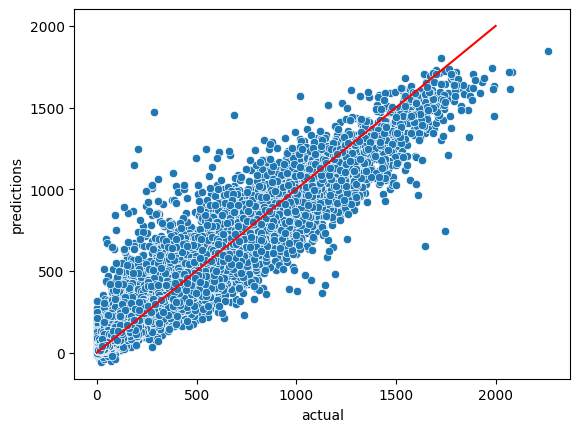

In [ ]:
pred = pd.DataFrame(predictions,columns=['predictions'])
pred
pred['actual'] = y_test.tolist()
pred

pred['difference'] = pred['actual']-pred['predictions']
pred

import seaborn as sns
xlims =(0,2000)
ax = sns.scatterplot(data=pred,x='actual',y='predictions')
ax.plot(xlims,xlims, color='r')
plt.show()

In [ ]:
def exportPredictions():
    holdout = pd.read_csv(
        "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/biking_holdout_test_mini.csv"
    )

    dataClean(holdout)

    holdout = holdout[features]      # same feature order
    holdout = norm.transform(holdout)  # VERY IMPORTANT

    holdoutPredictions = model.predict(holdout)
    holdoutPredictions = np.round(holdoutPredictions, 1)

    holdout_predictions_df = pd.DataFrame(holdoutPredictions, columns=["predictions"])
    holdout_predictions_df.to_csv("team4-module4-predictions.csv", index=False)

    print(holdout_predictions_df.head())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

exportPredictions()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
   predictions
0    73.300003
1    33.400002
2    28.400000
3    25.000000
4    30.100000
